0mM TEMPO: B = 0.0739 * I^0.7248  (R^2 = 0.9988)
1mM TEMPO: B = 0.1131 * I^0.5793  (R^2 = 0.9988)
5mM TEMPO: B = 0.0685 * I^0.6069  (R^2 = 0.9699)


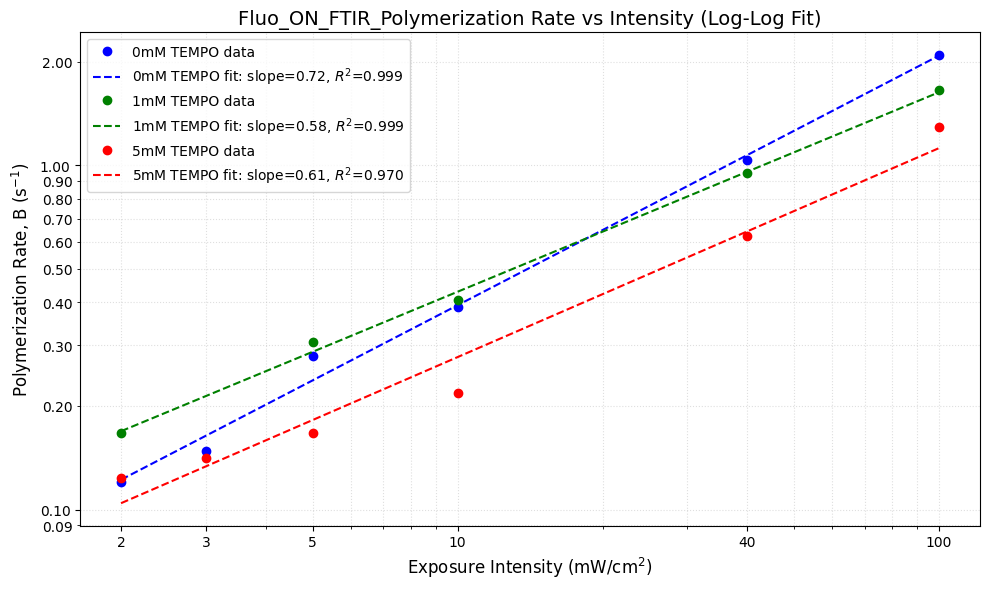

0mM TEMPO: inhibition time C= 8.9311 * I^-0.4193  (R^2 = 0.9345)
1mM TEMPO: inhibition time C= 25.5705 * I^-0.6185  (R^2 = 0.9538)
5mM TEMPO: inhibition time C= 78.7447 * I^-0.7816  (R^2 = 0.9828)


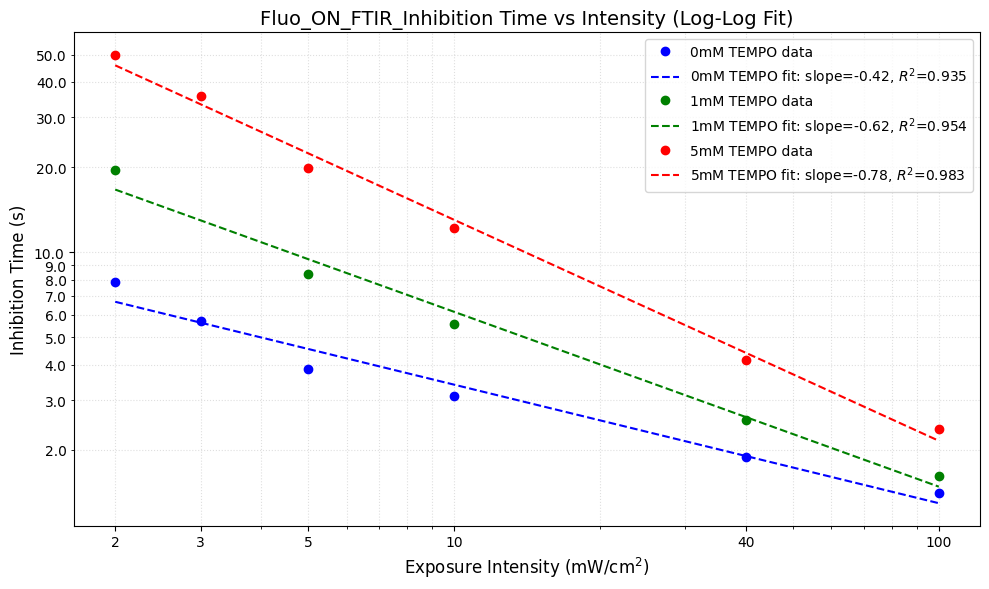

In [111]:
#This is for FTIR&FL SYNC DATASET 0/1/5mM TEMPO (Jack Shared on 26/09/10)
#Log-log (power-law) fit of polymerization rate B (and Inhibition Time)vs excitation intensity

### ALL ROI_AIE_FLuo HERE!!!!!!###
### ALL ROI_AIE_FLuo HERE!!!!!!###
### ALL ROI_AIE_FLuo HERE!!!!!!###

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter,FixedLocator, FuncFormatter

datasets = {
    '0mM TEMPO': {
        'intensity': np.array([2,3,5,10,40,100], dtype=float),
        'polymerization_rate': np.array([0.1204,0.1475,0.2790,0.3875,1.0329,2.0925]),
        'inhibition_time': np.array([7.8622,5.7300,3.8752,3.1085,1.8792,1.4054]),
        'color': 'blue',
    },
    
    '1mM TEMPO': {
        'intensity': np.array([2,5,10,40,100], dtype=float), #missing 3mW data for 1mM TEMPO
        'polymerization_rate': np.array([0.1665,0.3067,0.4058,0.9462,1.6570]),
        'inhibition_time': np.array([19.4932,8.3693,5.5677,2.5529,1.6164]),
        'color': 'green',
        },
    
    '5mM TEMPO': {
        'intensity': np.array([2,3,5,10,40,100], dtype=float),
        'polymerization_rate': np.array([0.1232,0.1412, 0.1664, 0.2188, 0.6222,1.2869]),
        'inhibition_time': np.array([49.9235,35.7624, 19.7756, 12.1795, 4.1474,2.3686]),
        'color': 'red',
    },
}

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    I, polymerization_rate, color = d['intensity'], d['polymerization_rate'], d['color']
    log_I, log_b = np.log10(I), np.log10(polymerization_rate)

    n_fit, log_k = np.polyfit(log_I, log_b, 1)
    b_fit = 10**log_k * I**n_fit
    r2 = 1 - np.sum((polymerization_rate - b_fit)**2) / np.sum((polymerization_rate - np.mean(polymerization_rate))**2)

    plt.loglog(I, polymerization_rate, 'o', color=color, label=f'{label} data')
    I_smooth = np.logspace(np.log10(I.min()), np.log10(I.max()), 50)
    
    plt.loglog(I_smooth, 10**log_k * I_smooth**n_fit, '--', color=color,
               label=f'{label} fit: slope={n_fit:.2f}, $R^2$={r2:.3f}')
    print(f'{label}: B = {10**log_k:.4f} * I^{n_fit:.4f}  (R^2 = {r2:.4f})')
plt.xlabel('Exposure Intensity (mW/cm$^2$)',fontsize=12)
plt.ylabel('Polymerization Rate, B (s$^{-1}$)',fontsize=12)
plt.title("Fluo_ON_FTIR_Polymerization Rate vs Intensity (Log-Log Fit)",fontsize=14)
# --- finer ticks ---
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([ 2,3,5,10,40,100]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()


# Log-log (power-law) fit of inhibition time vs excitation intensity

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    intensity = d['intensity']
    inhibition_time = d['inhibition_time']
    color = d['color']
    log_intensity, log_time = np.log10(intensity), np.log10(inhibition_time)

    slope, log_k = np.polyfit(log_intensity, log_time, 1)
    time_fit = 10**log_k * intensity**slope
    r2 = 1 - np.sum((inhibition_time - time_fit)**2) / np.sum((inhibition_time - np.mean(inhibition_time))**2)

    plt.loglog(intensity, inhibition_time, 'o', color=color, label=f'{label} data')
    intensity_smooth = np.logspace(np.log10(intensity.min()), np.log10(intensity.max()), 50)
    fit_values = 10**log_k * intensity_smooth**slope
    plt.loglog(intensity_smooth, fit_values, '--', color=color,
               label=f'{label} fit: slope={slope:.2f}, $R^2$={r2:.3f}')

    # annotation_x = intensity_smooth[int(0.72 * len(intensity_smooth))]
    # annotation_y = 10**log_k * annotation_x**slope
    # ax.annotate(f'slope = {slope:.2f}', (annotation_x, annotation_y),
    #             color=color, fontsize=12, ha='right', va='bottom',
    #             xytext=(-250, 100), textcoords='offset points')

    print(f'{label}: inhibition time C= {10**log_k:.4f} * I^{slope:.4f}  (R^2 = {r2:.4f})')

plt.xlabel('Exposure Intensity (mW/cm$^2$)', fontsize=12)
plt.ylabel('Inhibition Time (s)', fontsize=12)
plt.title('Fluo_ON_FTIR_Inhibition Time vs Intensity (Log-Log Fit)', fontsize=14)
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([ 2,3,5,10,40,100]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()


0mM TEMPO: B = 0.2262 * I^0.5009  (R^2 = 0.9773)
1mM TEMPO: B = 0.1252 * I^0.5622  (R^2 = 0.9926)
5mM TEMPO: B = 0.0407 * I^0.7172  (R^2 = 0.9926)


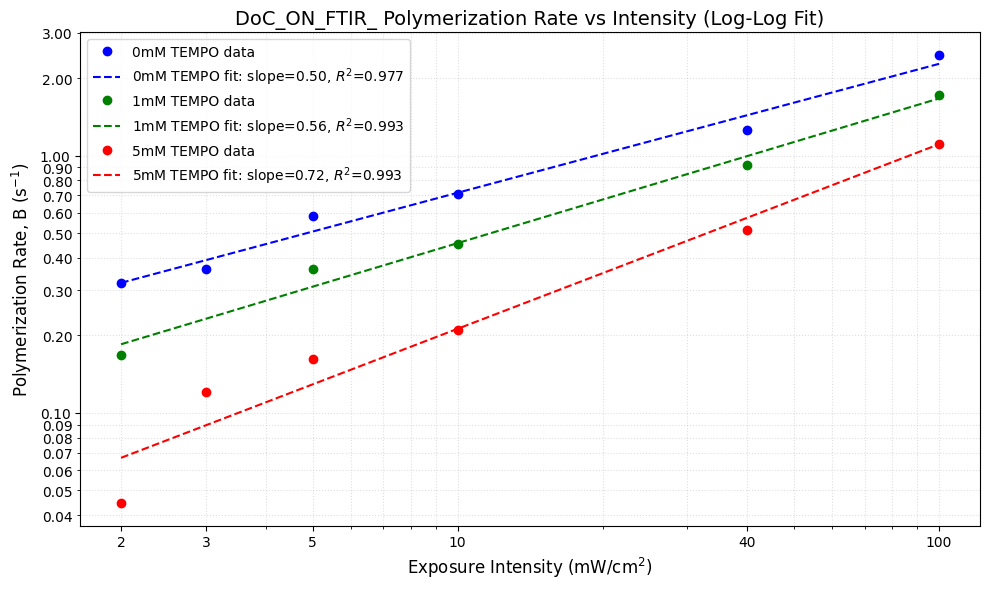

0mM TEMPO: inhibition time C= 8.9416 * I^-0.9848  (R^2 = 0.9929)
1mM TEMPO: inhibition time C= 34.7066 * I^-1.0637  (R^2 = 0.9890)
5mM TEMPO: inhibition time C= 91.5841 * I^-0.9911  (R^2 = 0.9927)


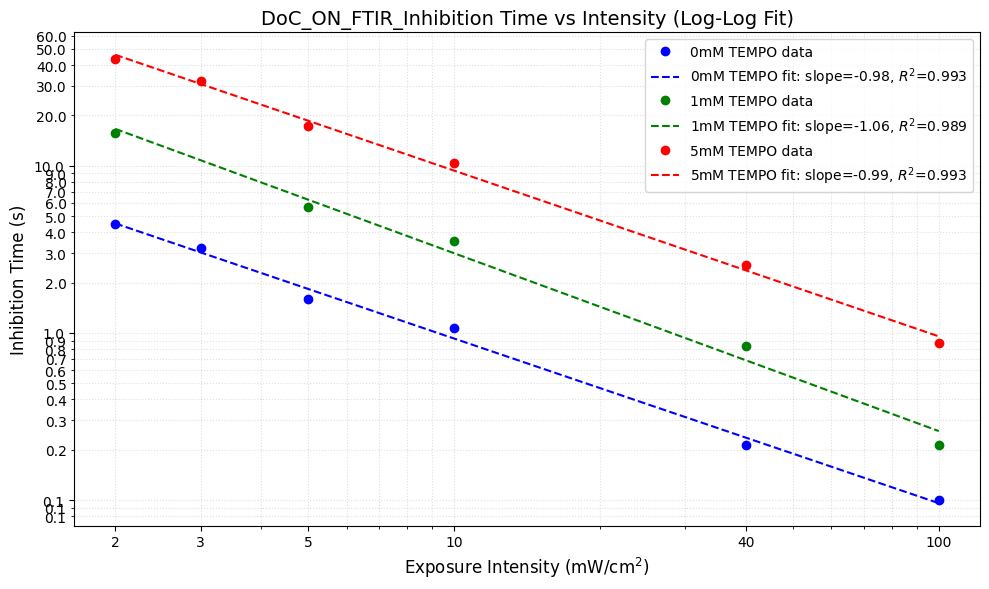

In [112]:
#This is for FTIR&FL SYNC DATASET 0/1/5mM TEMPO (Jack Shared on 26/09/10)
#Log-log (power-law) fit of polymerization rate B (and Inhibition Time)vs excitation intensity

### ALL FTIR HERE!!!!!!###
### ALL FTIR HERE!!!!!!###
### ALL FTIR HERE!!!!!!###


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter,FixedLocator, FuncFormatter


datasets = {
    '0mM TEMPO': {
        'intensity': np.array([2,3,5,10,40,100], dtype=float),
        'polymerization_rate': np.array([0.3199,0.3631,0.5829,0.7089,1.2575,2.4635]), ##Dont use 100mW data for 0mM TEMPO if target is Inhibition Time!
        'inhibition_time': np.array([4.4825,3.2121,1.6009,1.0640,0.2148,0.1000]), 
        #Here 0.1 is just a random small number to avoid log(0) error, 
        # but it is not a real data point. Do not use it for fitting!
        'color': 'blue',
    },
    '1mM TEMPO': {
            'intensity': np.array([2,5,10,40,100], dtype=float), 
            'polymerization_rate': np.array([0.1676,0.3629,0.4525,0.9191, 1.7138]), #missing 3mW data for 1mM TEMPO
            'inhibition_time': np.array([15.5983,5.6456,3.5311,0.8340, 0.2135]),
            'color': 'green',
        },
    '5mM TEMPO': {
        'intensity': np.array([2,3,5,10,40,100], dtype=float), #Something wrong with the 5mW data
        'polymerization_rate': np.array([0.0446,0.1202, 0.1620, 0.2099, 0.5153,1.11037]),
        'inhibition_time': np.array([43.6311,32.0478, 17.1715, 10.3863, 2.5542,0.8739]),
        'color': 'red',
    },
}

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    I, polymerization_rate, color = d['intensity'], d['polymerization_rate'], d['color']
    log_I, log_b = np.log10(I), np.log10(polymerization_rate)

    n_fit, log_k = np.polyfit(log_I, log_b, 1)
    b_fit = 10**log_k * I**n_fit
    r2 = 1 - np.sum((polymerization_rate - b_fit)**2) / np.sum((polymerization_rate - np.mean(polymerization_rate))**2)

    plt.loglog(I, polymerization_rate, 'o', color=color, label=f'{label} data')
    I_smooth = np.logspace(np.log10(I.min()), np.log10(I.max()), 50)
    
    plt.loglog(I_smooth, 10**log_k * I_smooth**n_fit, '--', color=color,
               label=f'{label} fit: slope={n_fit:.2f}, $R^2$={r2:.3f}')
    print(f'{label}: B = {10**log_k:.4f} * I^{n_fit:.4f}  (R^2 = {r2:.4f})')
plt.xlabel('Exposure Intensity (mW/cm$^2$)',fontsize=12)
plt.ylabel('Polymerization Rate, B (s$^{-1}$)',fontsize=12)
plt.title("DoC_ON_FTIR_ Polymerization Rate vs Intensity (Log-Log Fit)",fontsize=14)
# --- finer ticks ---
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([ 2,3,5,10,40,100]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()


# Log-log (power-law) fit of inhibition time vs excitation intensity

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    intensity = d['intensity']
    inhibition_time = d['inhibition_time']
    color = d['color']
    log_intensity, log_time = np.log10(intensity), np.log10(inhibition_time)

    slope, log_k = np.polyfit(log_intensity, log_time, 1)
    time_fit = 10**log_k * intensity**slope
    r2 = 1 - np.sum((inhibition_time - time_fit)**2) / np.sum((inhibition_time - np.mean(inhibition_time))**2)

    plt.loglog(intensity, inhibition_time, 'o', color=color, label=f'{label} data')
    intensity_smooth = np.logspace(np.log10(intensity.min()), np.log10(intensity.max()), 50)
    fit_values = 10**log_k * intensity_smooth**slope
    plt.loglog(intensity_smooth, fit_values, '--', color=color,
               label=f'{label} fit: slope={slope:.2f}, $R^2$={r2:.3f}')

    # annotation_x = intensity_smooth[int(0.72 * len(intensity_smooth))]
    # annotation_y = 10**log_k * annotation_x**slope
    # ax.annotate(f'slope = {slope:.2f}', (annotation_x, annotation_y),
    #             color=color, fontsize=12, ha='right', va='bottom',
    #             xytext=(-50, -10), textcoords='offset points')

    print(f'{label}: inhibition time C= {10**log_k:.4f} * I^{slope:.4f}  (R^2 = {r2:.4f})')

plt.xlabel('Exposure Intensity (mW/cm$^2$)', fontsize=12)
plt.ylabel('Inhibition Time (s)', fontsize=12)
plt.title('DoC_ON_FTIR_Inhibition Time vs Intensity (Log-Log Fit)', fontsize=14)
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([ 2,3,5,10,40,100]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()


In [113]:
# In this cell, we need to translate Fluo data to FTIR data

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter

#ax = plt.gca()
datasets = {
    '0mM TEMPO': {
        'intensity': np.array([2,3,5,10,40,100], dtype=float), #missing 100mW data for 0mM TEMPO
        'k_Fluo':0.0739,
        'n_Fluo':0.7248,

        'k_FTIR':0.2262,
        'n_FTIR':0.5009,
        'color': 'blue',
    },
    
    '1mM TEMPO': {
        'intensity': np.array([2,5,10,40,100], dtype=float), #missing 3mW and 100mW data for 1mM TEMPO
        'k_FLuo':0.1131,
        'n_Fluo':0.5793,

        'k_FTIR':0.1252,
        'n_FTIR':0.5622,
        'color': 'green',
        },
    
    '5mM TEMPO': {
        'intensity': np.array([2,3,5,10,40,100], dtype=float),
        'k_Fluo':0.0685,
        'n_Fluo':0.6069,

        'k_FTIR':0.0407,
        'n_FTIR':0.7172,
        'color': 'red',
    },
}

Fitted fluorescence B:       0.3623 s^-1
Fitted fluorescence C:       3.0910 s
Transferred FTIR B:          0.6787 s^-1
Transferred FTIR C:          0.7946 s
Experimentally fitted FTIR B:      0.6201 s^-1
Experimentally fitted FTIR C:      1.0397 s
B-rate Transfer error:              +9.4%
C-time Transfer error:              -23.6%


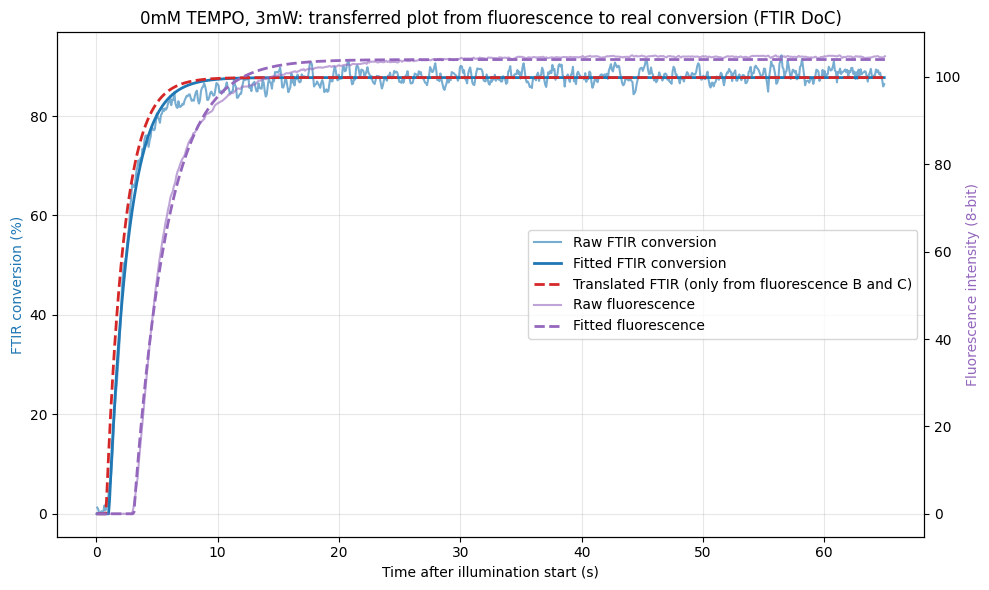

In [114]:
# Rate-transfer demonstration on raw 0mM TEMPO, 2mW data
# This cell transfers B and C; A is used only as a display scale.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data_dir = Path('PastDataFiles/20260910/FTIR_allTempoFL/0mM_TEMPO/10mW/r1/data')
start_time_s = 15.0  # Same illumination-time convention as DoC curve.ipynb

ftir_df = pd.read_csv(data_dir / 'ftir_timeseries.csv')
fluo_df = pd.read_csv(data_dir / 'roi_fluorescent_intensity_timeseries.csv')

ftir_rows = ftir_df.loc[ftir_df['camera_time_s'] >= start_time_s]
fluo_rows = fluo_df.loc[fluo_df['camera_time_s'] >= start_time_s]
t_ftir = ftir_rows['camera_time_s'].to_numpy(float) - start_time_s
t_fluo = fluo_rows['camera_time_s'].to_numpy(float) - start_time_s
raw_ftir = ftir_rows['smoothed_conversion_percent'].to_numpy(float).clip(min=0)
raw_fluo = fluo_rows['video_roi_mean_8bit'].to_numpy(float).clip(min=0)

def delayed_exponential(t, a, b, c):
    return np.where(t < c, 0.0, a * (1.0 - np.exp(-b * (t - c))))

def fit_rate(time_s, signal):
    parameters, _ = curve_fit(
        delayed_exponential, time_s, signal,
        p0=(signal.max(), 0.15, 1.0),
        bounds=([0, 0, 0], [np.inf, np.inf, time_s.max()]),
        maxfev=20000,
    )
    return parameters

A_Fluo, B_Fluo, C_Fluo = fit_rate(t_fluo, raw_fluo)
A_FTIR, B_FTIR_fitted, C_FTIR = fit_rate(t_ftir, raw_ftir)

# 0mM TEMPO transfer: B_Fluo = k_Fluo * I**n_Fluo and B_FTIR = k_FTIR * I**n_FTIR
k_Fluo, n_Fluo = 0.0739, 0.7248
k_FTIR, n_FTIR = 0.2262, 0.5009
B_FTIR_predicted = (
    k_FTIR * k_Fluo ** (-n_FTIR / n_Fluo)
    * B_Fluo ** (n_FTIR / n_Fluo)
)
# 0mM TEMPO inhibition-time transfer, excluding the artificial 100mW FTIR C value.
k_C_Fluo, n_C_Fluo = 9.4762425, -0.4595687
k_C_FTIR, n_C_FTIR = 9.2172028, -1.0054337
C_FTIR_predicted = (
    k_C_FTIR * k_C_Fluo ** (-n_C_FTIR / n_C_Fluo)
    * C_Fluo ** (n_C_FTIR / n_C_Fluo)
)
# A is the plateau from the directly fitted FTIR curve, used for visualization only.
A_FTIR_display = A_FTIR
translated_ftir_rate_only = np.where(
    t_ftir < C_FTIR_predicted, 0.0,
    A_FTIR_display * (1.0 - np.exp(-B_FTIR_predicted * (t_ftir - C_FTIR_predicted))),
)
rate_error_percent = 100 * (B_FTIR_predicted - B_FTIR_fitted) / B_FTIR_fitted
time_error_percent = 100 * (C_FTIR_predicted - C_FTIR) / C_FTIR

print(f'Fitted fluorescence B:       {B_Fluo:.4f} s^-1')
print(f'Fitted fluorescence C:       {C_Fluo:.4f} s')
print(f'Transferred FTIR B:          {B_FTIR_predicted:.4f} s^-1')
print(f'Transferred FTIR C:          {C_FTIR_predicted:.4f} s')
print(f'Experimentally fitted FTIR B:      {B_FTIR_fitted:.4f} s^-1')
print(f'Experimentally fitted FTIR C:      {C_FTIR:.4f} s')
#print(f'Translated-curve A:           {A_FTIR_display:.2f}% (fitted FTIR plateau)')
print(f'B-rate Transfer error:              {rate_error_percent:+.1f}%')
print(f'C-time Transfer error:              {time_error_percent:+.1f}%')

fig, ax_ftir = plt.subplots(figsize=(10, 6))
ax_fluo = ax_ftir.twinx()

ftir_line = ax_ftir.plot(t_ftir, raw_ftir, color='tab:blue', alpha=0.6, label='Raw FTIR conversion')
fitted_ftir_curve = delayed_exponential(t_ftir, A_FTIR, B_FTIR_fitted, C_FTIR)
fitted_line = ax_ftir.plot(t_ftir, fitted_ftir_curve, color='tab:blue', linewidth=2, label='Fitted FTIR conversion')

fluo_line = ax_fluo.plot(t_fluo, raw_fluo, color='tab:purple', alpha=0.6,label='Raw fluorescence')
fitted_fluo_curve = delayed_exponential(t_fluo, A_Fluo, B_Fluo, C_Fluo)
fitted_fluo_line = ax_fluo.plot(
    t_fluo, fitted_fluo_curve, '--', color='tab:purple', linewidth=2,
    label='Fitted fluorescence',
)
translated_line = ax_ftir.plot(
    t_ftir, translated_ftir_rate_only, '--', color='tab:red', linewidth=2,
    label='Translated FTIR (only from fluorescence B and C)',
)
ax_ftir.set_xlabel('Time after illumination start (s)')
ax_ftir.set_ylabel('FTIR conversion (%)', color='tab:blue')

ax_fluo.set_ylabel('Fluorescence intensity (8-bit)', color='tab:purple')
ax_ftir.set_title('0mM TEMPO, 3mW: transferred plot from fluorescence to real conversion (FTIR DoC)')
ax_ftir.grid(True, alpha=0.3)
# ax_ftir.text(
#     0.03, 0.97,
#     f'B_Fluo = {B_Fluo:.4f} s^-1\n'
#     f'Predicted B_FTIR = {B_FTIR_predicted:.4f} s^-1\n'
#     f'Fitted B_FTIR = {B_FTIR_fitted:.4f} s^-1\n'
#     f'Predicted C_FTIR = {C_FTIR_predicted:.4f} s\n'
#     f'Rate error = {rate_error_percent:+.1f}%',
#     transform=ax_ftir.transAxes, va='top',
#     bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '0.7'},
# )
lines = ftir_line + fitted_line + translated_line + fluo_line + fitted_fluo_line
ax_ftir.legend(lines, [line.get_label() for line in lines], loc='center right')
plt.tight_layout()
plt.show()
